# Part A: Fixed NumPy Implementation

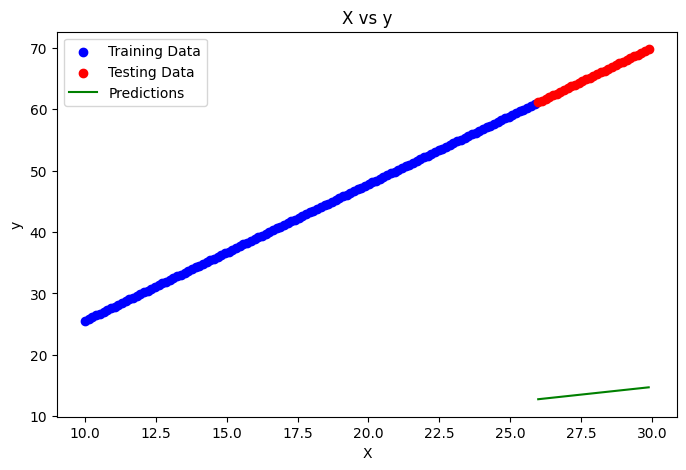

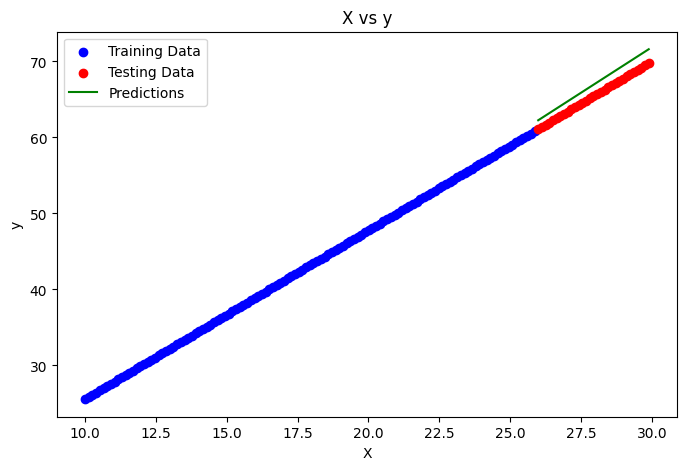

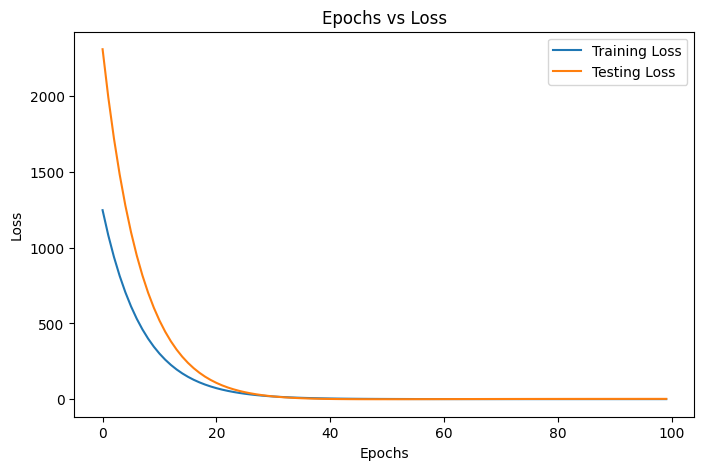

Learned parameters: w = 2.3966, b = -0.0347


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Generate Synthetic Data
X = np.arange(10, 30, 0.13)
y = 2.222 * X + 3.333

# Step 3: Train-Test Split
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# Step 4: Visualize Function
def plot_data(X_train, y_train, X_test, y_test, predictions=None):
    plt.figure(figsize=(8, 5))
    plt.scatter(X_train, y_train, c='b', label='Training Data')
    plt.scatter(X_test, y_test, c='r', label='Testing Data')
    if predictions is not None:
        plt.plot(X_test, predictions, c='g', label='Predictions')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('X vs y')
    plt.legend()
    plt.show()

# Step 5: Initialize Parameters
np.random.seed(42)
w = np.random.randn()
b = np.random.randn()

# Step 6: Define Loss Function
def loss_fn(y_actual, y_out):
    return np.mean(np.square(y_actual - y_out))

# Step 7: Predictions Before Training
y_out = X_test * w + b
plot_data(X_train, y_train, X_test, y_test, predictions=y_out)

# Step 8: Training Loop
lr = 0.0001  # Reduced learning rate for numerical stability
epochs = 100
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    # Forward pass
    train_preds = X_train * w + b
    train_loss = loss_fn(y_train, train_preds)

    # Compute gradients
    gradientw = (-2 / len(X_train)) * np.sum((y_train - train_preds) * X_train)
    gradientb = (-2 / len(X_train)) * np.sum(y_train - train_preds)

    # Update parameters
    w = w - gradientw * lr
    b = b - gradientb * lr

    # Evaluate on test data
    test_preds = X_test * w + b
    test_loss = loss_fn(y_test, test_preds)

    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

# Step 9 & 10: Results & Curves
y_out = X_test * w + b
plot_data(X_train, y_train, X_test, y_test, predictions=y_out)

plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(f"Learned parameters: w = {w:.4f}, b = {b:.4f}")

# Part B: Fixed PyTorch Implementation

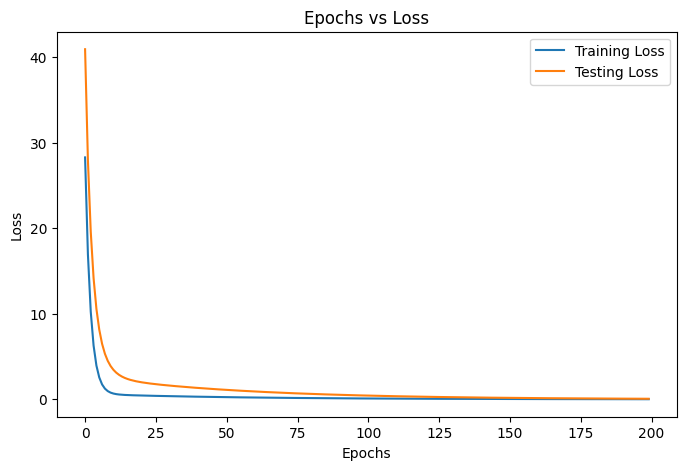

Learned Parameters -> Weight: 5.1120, Bias: 3.4510


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"

# Step 2: Data Generation & Preprocessing
X = np.arange(0, 1, 0.02, dtype=np.float32)
y = 5.66 * X + 3.227

split = int(len(X) * 0.8)
X_train_np, y_train_np = X[:split], y[:split]
X_test_np, y_test_np = X[split:], y[split:]

X_train = torch.from_numpy(X_train_np).unsqueeze(1).to(device)
y_train = torch.from_numpy(y_train_np).unsqueeze(1).to(device)
X_test = torch.from_numpy(X_test_np).unsqueeze(1).to(device)
y_test = torch.from_numpy(y_test_np).unsqueeze(1).to(device)

# Step 3: Define Model
class LinearRegressionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

# Step 4 & 6: Instantiate & Setup
torch.manual_seed(42)
model_1 = LinearRegressionNetwork().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.1)

# Step 7: Training Loop
epochs = 200
train_loss_list, test_loss_list = [], []

for epoch in range(epochs):
    model_1.train()
    train_pred = model_1(X_train)
    loss = loss_fn(train_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    train_loss_list.append(loss.cpu().detach().numpy())
    test_loss_list.append(test_loss.cpu().detach().numpy())

# Plot Loss Curves
plt.figure(figsize=(8, 5))
plt.plot(range(epochs), train_loss_list, label="Training Loss")
plt.plot(range(epochs), test_loss_list, label="Testing Loss")
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

print(f"Learned Parameters -> Weight: {model_1.weights.item():.4f}, Bias: {model_1.bias.item():.4f}")